# ANUGA Rainfall-Runoff Simulation with GPU Support

This notebook simulates long-duration rainfall events using ANUGA with optional GPU acceleration.

## Features:
- **GPU Support**: Uses CuPy for GPU acceleration (if available)
- **Long Simulations**: Optimized for extended simulation times
- **Checkpointing**: Automatic saving of simulation state for recovery
- **Memory Management**: Efficient handling of large domains
- **Progress Monitoring**: Real-time statistics and visualization

## Quick Start Guide

### For Long Simulations:
1. **Run Cell 1-3** to set up the environment and configuration
2. **Adjust settings in Cell 3** (see below) for your simulation duration
3. **Run Cell 4** to create the domain and enable GPU (if available)
4. **Run Cell 5** to execute the simulation (this is the long-running cell)
5. **Run Cell 6-8** to visualize results

### Configuration Options (in Cell 3):
```python
config.total_simulation_hours = 24.0  # Set to desired duration (e.g., 48, 72, 168 for 1 week)
config.rainfall_duration_hours = 1.0   # How long rain falls
config.rainfall_intensity_mm_hr = 10.0 # Rainfall intensity
config.output_interval_minutes = 30.0  # How often to save results
config.checkpoint_interval_hours = 2.0 # How often to save recovery points
config.maximum_triangle_area = 50000   # Smaller = more accurate but slower
```

### Performance Tips:
- **GPU**: Install CuPy for 5-10x speedup (see GPU Setup cell)
- **Mesh Size**: Increase `maximum_triangle_area` for faster simulation
- **Output Interval**: Larger intervals = less disk I/O
- **Checkpoints**: Enable for long runs so you can resume if interrupted

## ⚠️ IMPORTANT: GPU Configuration Update

**Changes made to enable proper GPU acceleration:**

1. **Added Flow Algorithm Setup** - ANUGA's GPU mode requires `set_flow_algorithm('DE0')` and `set_low_froude(0)` to be compatible with CUDA kernels

2. **Added GPU Verification Test** - New cell after domain setup that:
   - Tests actual GPU kernel execution
   - Runs a tiny evolution to trigger kernel compilation
   - Monitors GPU memory allocation
   - Confirms GPU is truly active

3. **Enhanced Progress Monitoring** - Simulation cell now shows:
   - Current GPU memory usage during simulation
   - Clear indicators when GPU mode is active
   - Instructions to use `nvidia-smi` for verification

**Why `nvidia-smi` showed no Python process before:**
- CuPy was installed and could create arrays
- But ANUGA wasn't actually using GPU for computation
- Likely missing the `DE0` flow algorithm requirement
- Or GPU interface wasn't properly initialized

**To verify GPU is working:**
1. Run the domain setup cell (Cell 9)
2. Run the new GPU verification cell (Cell 10)
3. **Open a terminal and run:** `nvidia-smi -l 1`
4. Run the simulation cell (Cell 11)
5. You should see Python process with GPU memory usage in nvidia-smi

If you still see no Python process in `nvidia-smi`, the GPU is NOT being used.

In [14]:
import anuga 
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import time

# Check for GPU support
GPU_AVAILABLE = True
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✓ CuPy found - GPU acceleration ENABLED")
    print(f"  GPU: {cp.cuda.Device()}")
    print(f"  CuPy version: {cp.__version__}")
except ImportError:
    print("✗ CuPy not found - Running on CPU only")
    print("  To enable GPU: pip install cupy-cuda11x (or cupy-cuda12x for CUDA 12)")
    print("  Note: Requires NVIDIA GPU with CUDA installed")

print(f"ANUGA version: {anuga.__version__ if hasattr(anuga, '__version__') else 'Unknown'}")
print(f"NumPy version: {np.__version__}")

✓ CuPy found - GPU acceleration ENABLED
  GPU: <CUDA Device 0>
  CuPy version: 13.6.0
ANUGA version: 3.2.1rc17
NumPy version: 2.1.0


In [15]:
# CHECK GPU AND SYSTEM CAPABILITIES
import platform

print("="*70)
print("SYSTEM INFORMATION")
print("="*70)
print(f"OS: {platform.system()} {platform.release()}")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")

# Check for GPU
if GPU_AVAILABLE:
    print("\n" + "="*70)
    print("GPU INFORMATION")
    print("="*70)
    try:
        import cupy as cp
        print(f"CuPy version: {cp.__version__}")
        print(f"GPU Device: {cp.cuda.Device()}")
        
        # Get GPU memory info
        mempool = cp.get_default_memory_pool()
        print(f"GPU Memory - Used: {mempool.used_bytes()/1e9:.2f} GB")
        print(f"GPU Memory - Total: {mempool.total_bytes()/1e9:.2f} GB")
        
        # CUDA version
        print(f"CUDA Version: {cp.cuda.runtime.runtimeGetVersion()}")
        print(f"CUDA Compute Capability: {'.'.join(map(str, cp.cuda.Device().compute_capability))}")
        
        # Number of GPUs
        n_gpus = cp.cuda.runtime.getDeviceCount()
        print(f"Available GPUs: {n_gpus}")
        
        print("\n✓ GPU acceleration is READY")
    except Exception as e:
        print(f"GPU check error: {e}")
else:
    print("\n✗ GPU not available - will use CPU")
    print("  For GPU support, install CuPy matching your CUDA version")

print("="*70)

SYSTEM INFORMATION
OS: Windows 11
Python: 3.13.7
NumPy: 2.1.0

GPU INFORMATION
CuPy version: 13.6.0
GPU Device: <CUDA Device 0>
GPU Memory - Used: 0.00 GB
GPU Memory - Total: 0.00 GB
CUDA Version: 13000
CUDA Compute Capability: 8.6
Available GPUs: 1

✓ GPU acceleration is READY


In [16]:
import os
import sys

# --- GDAL WINDOWS FIX ---
# Anaconda on Windows often hides the GDAL DLLs in the Library\bin folder.
# We must add this to the system path so Python can find '_gdal'.

# 1. Get the absolute path to your current environment's 'Library/bin'
conda_library_bin = os.path.join(sys.prefix, 'Library', 'bin')

# 2. Add it to the system PATH environment variable
if os.path.exists(conda_library_bin):
    os.environ['PATH'] = conda_library_bin + os.pathsep + os.environ['PATH']
    
    # 3. For Python 3.8+, we might also need this explicit call:
    if hasattr(os, 'add_dll_directory'):
        try:
            os.add_dll_directory(conda_library_bin)
        except Exception:
            pass
else:
    print(f"WARNING: Could not find Anaconda Library/bin at: {conda_library_bin}")
# ------------------------



## GPU Setup (Optional but Recommended)

To enable GPU acceleration for faster simulations, install CuPy:

```bash
# For CUDA 11.x
pip install cupy-cuda11x

# For CUDA 12.x
pip install cupy-cuda12x
```

**Requirements:**
- NVIDIA GPU with CUDA support
- CUDA Toolkit installed
- Matching CuPy version for your CUDA version

**Benefits:**
- 5-10x faster computation for large domains
- Enables much longer simulation times
- Better performance with high-resolution meshes

In [17]:
import pandas as pd
from shapely import wkt
import anuga
import os
from anuga import Domain, Geo_reference
from osgeo import gdal, osr
import numpy as np

# --- HELPER FUNCTION ---
def get_tiff_details(tiff_path):
    """Extract zone, proj4, EPSG, and hemisphere from a GeoTIFF."""
    if not os.path.exists(tiff_path): 
        raise FileNotFoundError(f"{tiff_path}")
    ds = gdal.Open(tiff_path)
    if ds is None: 
        raise ValueError("GDAL could not open the file.")
    
    prj = ds.GetProjection()
    srs = osr.SpatialReference(wkt=prj)
    
    if srs.IsProjected():
        zone = srs.GetUTMZone()
        # Fallback for zone parsing
        if zone == 0:
            name = srs.GetAttrValue("PROJCS")
            if name:
                import re
                match = re.search(r"zone\s+(\d+)", name, re.IGNORECASE)
                if match: zone = int(match.group(1))
        
        proj4_str = srs.ExportToProj4()
        epsg = srs.GetAuthorityCode(None)
        
        # Determine hemisphere from EPSG
        hemisphere = 'northern'
        if epsg:
            if epsg.startswith('327'):
                hemisphere = 'southern'
            elif epsg.startswith('326'):
                hemisphere = 'northern'
        
        return zone, proj4_str, epsg, hemisphere
    else:
        raise ValueError("TIFF is not projected.")

def create_tiff_with_epsg(input_tiff, output_tiff, epsg_code):
    """Create a copy of the TIFF with explicit EPSG code."""
    print(f"Creating TIFF with EPSG:{epsg_code}: {output_tiff}")
    try:
        srs = osr.SpatialReference()
        srs.ImportFromEPSG(int(epsg_code))
        
        src_ds = gdal.Open(input_tiff)
        driver = gdal.GetDriverByName('GTiff')
        dst_ds = driver.CreateCopy(output_tiff, src_ds, strict=0)
        dst_ds.SetProjection(srs.ExportToWkt())
        
        dst_ds = None
        src_ds = None
        
        print(f"✓ Created corrected TIFF: {output_tiff}")
        return True
    except Exception as e:
        print(f"✗ Failed to create corrected TIFF: {e}")
        return False

class TopographyLoader:
    def __init__(self, domain):
        self.domain = domain

    def load_geotiff(self, tiff_path: str, quantity_name: str = 'elevation'):
        if not os.path.exists(tiff_path): 
            raise FileNotFoundError(f"{tiff_path}")
        print(f"Loading GeoTIFF: {tiff_path} into '{quantity_name}'...")
        try:
            self.domain.get_quantity(quantity_name).set_values_from_tif_file(tiff_path)
            print("✓ Topography loaded successfully.")
        except Exception as e:
            print(f"✗ Failed to load GeoTIFF. Reason: {e}")
            raise

class AnugaGeometryLoader:
    def parse_qgis_bounding_box(self, csv_path: str, buffer_distance: float = -5000.0) -> list:
        """Parse QGIS bounding box from CSV with optional buffering."""
        df = pd.read_csv(csv_path)
        wkt_string = df['WKT'].iloc[0]
        polygon_geom = wkt.loads(wkt_string)
        
        # Buffer to avoid NoData edges (negative = inward buffer)
        if buffer_distance != 0:
            polygon_geom = polygon_geom.buffer(buffer_distance) 

        coords_tuples = list(polygon_geom.exterior.coords)
        anuga_polygon = [list(pt) for pt in coords_tuples]
        
        if anuga_polygon[0] == anuga_polygon[-1]:
            anuga_polygon.pop()
        return anuga_polygon

class SimulationConfig:
    """Configuration class for simulation parameters."""
    def __init__(self):
        # Files
        self.csv_file = "bounder.csv"
        self.geotiff_file = "DEM_UTM.tif"
        self.corrected_tiff = "DEM_UTM_EPSG32643.tif"
        self.target_epsg = "32643"  # UTM Zone 43N
        
        # Domain parameters
        self.maximum_triangle_area = 25000  # m² (larger = faster, less accurate)
        self.buffer_distance = -5000.0  # meters (negative = inward)
        
        # Physical parameters
        self.friction_coefficient = 0.03  # Manning's n
        self.minimum_storable_height = 0.00001  # meters
        
        # Simulation parameters
        self.rainfall_intensity_mm_hr = 10.0  # mm/hr
        self.rainfall_duration_hours = 1.0  # hours
        self.total_simulation_hours = 24.0  # hours (can be very long)
        self.output_interval_minutes = 30.0  # minutes
        
        # Performance parameters
        self.use_gpu = GPU_AVAILABLE  # Auto-detect
        self.save_checkpoints = True
        self.checkpoint_interval_hours = 2.0  # hours
        
        # Output
        self.output_dir = 'outputs'
        self.simulation_name = 'rainfall_simulation'
    
    def get_rainfall_rate_mps(self):
        """Convert rainfall intensity to m/s."""
        return self.rainfall_intensity_mm_hr / (3600.0 * 1000.0)
    
    def print_summary(self):
        """Print configuration summary."""
        print("\n" + "="*70)
        print("SIMULATION CONFIGURATION")
        print("="*70)
        print(f"Domain mesh resolution: {self.maximum_triangle_area} m² per triangle")
        print(f"Rainfall: {self.rainfall_intensity_mm_hr} mm/hr for {self.rainfall_duration_hours} hours")
        print(f"Total simulation time: {self.total_simulation_hours} hours")
        print(f"Output interval: {self.output_interval_minutes} minutes")
        print(f"GPU acceleration: {'ENABLED' if self.use_gpu else 'DISABLED'}")
        print(f"Checkpointing: {'ENABLED' if self.save_checkpoints else 'DISABLED'}")
        if self.save_checkpoints:
            print(f"  Checkpoint interval: {self.checkpoint_interval_hours} hours")
        print("="*70)

# Initialize configuration
config = SimulationConfig()
config.print_summary()


SIMULATION CONFIGURATION
Domain mesh resolution: 25000 m² per triangle
Rainfall: 10.0 mm/hr for 1.0 hours
Total simulation time: 24.0 hours
Output interval: 30.0 minutes
GPU acceleration: ENABLED
Checkpointing: ENABLED
  Checkpoint interval: 2.0 hours


In [18]:
# ADJUST CONFIGURATION HERE FOR YOUR SIMULATION
# Modify these values before running the simulation

# Example configurations for different scenarios:

# Short test run (15 minutes)
# config.total_simulation_hours = 0.25
# config.rainfall_duration_hours = 0.083  # 5 minutes
# config.output_interval_minutes = 1.0

# Standard run (24 hours) - DEFAULT
# config.total_simulation_hours = 24.0
# config.rainfall_duration_hours = 1.0
# config.output_interval_minutes = 30.0
# config.checkpoint_interval_hours = 2.0

# Long run (1 week)
# config.total_simulation_hours = 168.0  # 7 days
# config.rainfall_duration_hours = 6.0   # 6 hour storm
# config.output_interval_minutes = 60.0  # 1 hour output
# config.checkpoint_interval_hours = 12.0 # 12 hour checkpoints

# Very long run (1 month) - for research/climate studies
config.total_simulation_hours = 720.0  # 30 days
config.rainfall_duration_hours = 12.0
config.output_interval_minutes = 120.0  # 2 hour output
config.checkpoint_interval_hours = 24.0  # daily checkpoints

# Mesh resolution (affects speed and accuracy)
# config.maximum_triangle_area = 100000  # Coarse/fast
# config.maximum_triangle_area = 50000   # Medium (default)
# config.maximum_triangle_area = 25000   # Fine/slow
config.maximum_triangle_area = 10000    # Very Fine (High GPU Load)

print("Current configuration:")
config.print_summary()

Current configuration:

SIMULATION CONFIGURATION
Domain mesh resolution: 10000 m² per triangle
Rainfall: 10.0 mm/hr for 12.0 hours
Total simulation time: 720.0 hours
Output interval: 120.0 minutes
GPU acceleration: ENABLED
Checkpointing: ENABLED
  Checkpoint interval: 24.0 hours


In [19]:
if __name__ == "__main__":
    # 1. GET TIFF CRS with hemisphere
    print("\n" + "="*70)
    print("STEP 1: READING GEOTIFF PROJECTION")
    print("="*70)
    zone_num, tiff_proj4, epsg_code, hemisphere = get_tiff_details(config.geotiff_file)
    print(f"✓ TIFF Zone: {zone_num}, EPSG: {epsg_code}, Hemisphere: {hemisphere}")
    
    # 2. Create corrected TIFF with explicit EPSG
    print("\n" + "="*70)
    print("STEP 2: PREPARING GEOTIFF")
    print("="*70)
    if not os.path.exists(config.corrected_tiff):
        create_tiff_with_epsg(config.geotiff_file, config.corrected_tiff, config.target_epsg)
    else:
        print(f"✓ Using existing corrected TIFF: {config.corrected_tiff}")
    
    # Verify the corrected TIFF
    _, _, corrected_epsg, corrected_hemisphere = get_tiff_details(config.corrected_tiff)
    print(f"✓ Corrected TIFF - EPSG: {corrected_epsg}, Hemisphere: {corrected_hemisphere}")
    
    # 3. LOAD POLYGON
    print("\n" + "="*70)
    print("STEP 3: LOADING BOUNDARY POLYGON")
    print("="*70)
    geo_loader = AnugaGeometryLoader() 
    bounding_polygon = geo_loader.parse_qgis_bounding_box(config.csv_file, config.buffer_distance)
    print(f"✓ Parsed {len(bounding_polygon)} vertices")
    print(f"  First 3 vertices: {bounding_polygon[:3]}")

    # 4. CREATE DOMAIN
    print("\n" + "="*70)
    print("STEP 4: CREATING COMPUTATIONAL MESH")
    print("="*70)
    num_segments = len(bounding_polygon)
    tags = {'exterior': list(range(num_segments))}

    print("Creating mesh (this may take a moment)...")
    start_time = time.time()
    domain = anuga.create_domain_from_regions(
        bounding_polygon, 
        boundary_tags=tags, 
        maximum_triangle_area=config.maximum_triangle_area
    )
    mesh_time = time.time() - start_time
    
    print(f"✓ Domain created with {domain.get_number_of_triangles():,} triangles in {mesh_time:.2f}s")
    print(f"  Domain area: {domain.get_area()/1e6:.2f} km²")
    print(f"  Initial geo_reference: {domain.geo_reference}")
    
    # IMPORTANT: Set flow algorithm for GPU compatibility
    # DE0 is required for GPU acceleration
    print("\n" + "="*70)
    print("STEP 4b: CONFIGURING FLOW ALGORITHM")
    print("="*70)
    domain.set_flow_algorithm('DE0')
    domain.set_low_froude(0)
    print("✓ Flow algorithm set to 'DE0' (required for GPU)")
    print("✓ Low Froude mode disabled (set to 0)")
    
    # 5. SET ZONE AND HEMISPHERE
    domain.geo_reference.set_zone(zone_num)
    domain.geo_reference.set_hemisphere(corrected_hemisphere)
    print(f"✓ Set zone={zone_num}, hemisphere={corrected_hemisphere}")

    # 6. LOAD TOPOGRAPHY
    print("\n" + "="*70)
    print("STEP 5: LOADING TOPOGRAPHY")
    print("="*70)
    topo_loader = TopographyLoader(domain)
    try:
        topo_loader.load_geotiff(config.corrected_tiff)
        
        elev = domain.get_quantity('elevation')
        print(f"✓ Elevation Range: {elev.get_minimum_value():.2f} to {elev.get_maximum_value():.2f} m")
        
    except Exception as e:
        print(f"✗ Execution halted: {e}")
        raise

    # 7. SETUP INITIAL CONDITIONS
    print("\n" + "="*70)
    print("STEP 6: SETTING INITIAL CONDITIONS")
    print("="*70)
    domain.set_quantity('friction', config.friction_coefficient)
    domain.set_quantity('stage', expression='elevation')  # Dry initial condition
    print(f"✓ Friction coefficient: {config.friction_coefficient}")
    print(f"✓ Initial condition: Dry bed (stage = elevation)")
    
    # 8. SETUP BOUNDARY CONDITIONS
    print("\n" + "="*70)
    print("STEP 7: SETTING BOUNDARY CONDITIONS")
    print("="*70)
    Bo = anuga.Dirichlet_boundary([-5.0, 0.0, 0.0])  # Outflow: stage below bed
    domain.set_boundary({'exterior': Bo})
    print("✓ Boundary condition: Dirichlet outflow on all exterior boundaries")
    
    # 9. CONFIGURE DOMAIN PARAMETERS
    domain.set_minimum_storable_height(config.minimum_storable_height)
    domain.set_name(config.simulation_name)
    domain.set_datadir(config.output_dir)
    
    # Create output directory
    os.makedirs(config.output_dir, exist_ok=True)
    
    # 10. ENABLE GPU IF AVAILABLE
    print("\n" + "="*70)
    print("STEP 8: CONFIGURING GPU ACCELERATION")
    print("="*70)
    if config.use_gpu and GPU_AVAILABLE:
        try:
            # Test CuPy with actual computation to ensure GPU is accessible
            import cupy as cp
            print("Testing GPU with CuPy computation...")
            test_array = cp.random.random((1000, 1000))
            test_result = cp.sum(test_array)
            print(f"✓ GPU computation test passed (result: {float(test_result):.4f})")
            
            # Set multiprocessor mode to 2 for GPU
            # This will call set_gpu_interface() which:
            # 1. Creates GPU_interface object
            # 2. Allocates GPU arrays
            # 3. Compiles GPU kernels
            domain.set_multiprocessor_mode(2)
            
            # Verify GPU interface was created
            if domain.gpu_interface is not None:
                print("✓ GPU acceleration ENABLED (multiprocessor_mode=2)")
                print(f"  GPU interface created: {type(domain.gpu_interface)}")
                print(f"  Domain multiprocessor mode: {domain.get_multiprocessor_mode()}")
                print("\n  GPU will be used for:")
                print("    - compute_fluxes_ext_central")
                print("    - extrapolate_second_order_edge_sw")
                print("    - Other shallow water computations")
                print("\n  ⚠ IMPORTANT: During simulation, check 'nvidia-smi' to verify GPU usage!")
            else:
                raise Exception("GPU interface was not created!")
            
        except Exception as e:
            import traceback
            print(f"✗ GPU setup failed: {e}")
            traceback.print_exc()
            print("  Falling back to CPU mode")
            
            # CPU Fallback with OpenMP
            import multiprocessing
            try:
                num_threads = multiprocessing.cpu_count()
                domain.set_omp_num_threads(num_threads)
                print(f"✓ CPU mode: Using {num_threads} OpenMP threads")
            except Exception as omp_e:
                print(f"  Warning: Could not set OpenMP threads: {omp_e}")
                domain.set_multiprocessor_mode(1)
            
            config.use_gpu = False
    else:
        # Use OpenMP for CPU parallelization
        import multiprocessing
        try:
            num_threads = multiprocessing.cpu_count()
            domain.set_omp_num_threads(num_threads)
            print(f"✓ CPU mode: Using {num_threads} OpenMP threads")
        except:
            domain.set_multiprocessor_mode(1)
            print("✓ CPU mode with OpenMP (multiprocessor_mode=1)")
    
    print("\n" + "="*70)
    print("DOMAIN SETUP COMPLETE")
    print("="*70)
    print(f"Triangles: {domain.get_number_of_triangles():,}")
    print(f"Area: {domain.get_area()/1e6:.2f} km²")
    print(f"Elevation: {elev.get_minimum_value():.2f} to {elev.get_maximum_value():.2f} m")
    print(f"Computation mode: {'GPU (CUDA/CuPy)' if config.use_gpu and domain.get_multiprocessor_mode() == 2 else 'CPU (OpenMP)'}")
    if config.use_gpu and domain.get_multiprocessor_mode() == 2:
        print(f"\n💡 TIP: Open a terminal and run 'nvidia-smi' during the next cell")
        print(f"         to verify GPU is being used during simulation!")
    print("="*70)


STEP 1: READING GEOTIFF PROJECTION
✓ TIFF Zone: 43, EPSG: 32643, Hemisphere: northern

STEP 2: PREPARING GEOTIFF
✓ Using existing corrected TIFF: DEM_UTM_EPSG32643.tif
✓ Corrected TIFF - EPSG: 32643, Hemisphere: northern

STEP 3: LOADING BOUNDARY POLYGON
✓ Parsed 4 vertices
  First 3 vertices: [[504986.60961398506, 3323822.6034833225], [504986.733658998, 3424639.745042332], [590499.2448509432, 3425024.0048475643]]

STEP 4: CREATING COMPUTATIONAL MESH
Creating mesh (this may take a moment)...
Setting omp_num_threads to 1
✓ Domain created with 1,334,205 triangles in 20.72s
  Domain area: 8666.64 km²
  Initial geo_reference: (zone=-1, easting=504986.609614, northing=3323822.603483, hemisphere=undefined)

STEP 4b: CONFIGURING FLOW ALGORITHM
✓ Flow algorithm set to 'DE0' (required for GPU)
✓ Low Froude mode disabled (set to 0)
✓ Set zone=43, hemisphere=northern

STEP 5: LOADING TOPOGRAPHY
Loading GeoTIFF: DEM_UTM_EPSG32643.tif into 'elevation'...
Setting omp_num_threads to 1
✓ Domain creat

Traceback (most recent call last):
  File "C:\Users\AlienX\AppData\Local\Temp\ipykernel_9900\4232530898.py", line 115, in <module>
    test_array = cp.random.random((1000, 1000))
  File "c:\Users\AlienX\anaconda3\envs\MTP\Lib\site-packages\cupy\random\_sample.py", line 155, in random_sample
    rs = _generator.get_random_state()
  File "c:\Users\AlienX\anaconda3\envs\MTP\Lib\site-packages\cupy\random\_generator.py", line 1307, in get_random_state
    rs = RandomState(seed)
  File "c:\Users\AlienX\anaconda3\envs\MTP\Lib\site-packages\cupy\random\_generator.py", line 57, in __init__
    from cupy_backends.cuda.libs import curand
ImportError: DLL load failed while importing curand: The specified module could not be found.


In [20]:
# VERIFY GPU SETUP AND TEST KERNEL EXECUTION
if config.use_gpu and GPU_AVAILABLE and domain.get_multiprocessor_mode() == 2:
    print("="*70)
    print("GPU VERIFICATION TEST")
    print("="*70)
    
    import cupy as cp
    
    # Check GPU memory before ANUGA operations
    print("\n1. GPU Memory Status:")
    mempool = cp.get_default_memory_pool()
    print(f"   Used: {mempool.used_bytes()/1e9:.3f} GB")
    print(f"   Total: {mempool.total_bytes()/1e9:.3f} GB")
    
    # Check if GPU interface is properly initialized
    print("\n2. GPU Interface Status:")
    if domain.gpu_interface is not None:
        print(f"   ✓ GPU interface exists: {type(domain.gpu_interface).__name__}")
        print(f"   ✓ Multiprocessor mode: {domain.get_multiprocessor_mode()}")
        
        # Check if arrays are allocated
        try:
            if hasattr(domain.gpu_interface, 'gpu_stage'):
                print(f"   ✓ GPU arrays allocated")
            else:
                print(f"   ⚠ GPU arrays may not be allocated yet")
        except:
            print(f"   ⚠ Could not check GPU array status")
    else:
        print(f"   ✗ GPU interface is None!")
    
    # Perform a small test evolution to trigger GPU kernel compilation
    print("\n3. Testing GPU Kernel Execution:")
    print("   Running tiny test evolution to activate GPU kernels...")
    
    try:
        # Save current time
        current_time = domain.get_time()
        
        # Do one tiny timestep
        for t in domain.evolve(yieldstep=0.01, finaltime=0.01):
            break
        
        print(f"   ✓ Test evolution completed (t={t:.4f}s)")
        print(f"   ✓ GPU kernels should now be compiled and loaded")
        print(f"\n   💡 NOW is the time to check 'nvidia-smi' in a terminal!")
        print(f"      You should see a Python process using GPU memory")
        
        # Check GPU memory after evolution
        mempool_after = cp.get_default_memory_pool()
        memory_increase = (mempool_after.used_bytes() - mempool.used_bytes()) / 1e6
        print(f"\n   GPU Memory increase: {memory_increase:.2f} MB")
        if memory_increase > 0:
            print(f"   ✓ GPU memory allocated - kernels are active!")
        else:
            print(f"   ⚠ No GPU memory increase - GPU may not be active")
            
    except Exception as e:
        print(f"   ✗ Test evolution failed: {e}")
        print(f"      GPU may not be properly configured")
    
    print("\n" + "="*70)
    print("GPU verification complete. Proceed to full simulation.")
    print("="*70)
    
else:
    print("GPU not enabled - skipping GPU verification test")
    print(f"Config use_gpu: {config.use_gpu}")
    print(f"GPU available: {GPU_AVAILABLE}")
    if hasattr(domain, 'get_multiprocessor_mode'):
        print(f"Multiprocessor mode: {domain.get_multiprocessor_mode()}")

GPU not enabled - skipping GPU verification test
Config use_gpu: False
GPU available: True
Multiprocessor mode: 1


## GPU Monitoring Instructions

Before running the simulation cell below, you can monitor GPU usage in real-time:

### Option 1: Windows Terminal
Open a new PowerShell/CMD terminal and run:
```powershell
nvidia-smi -l 1
```
This will update every 1 second showing GPU usage.

### Option 2: From VS Code Terminal
You can also run this in the VS Code terminal while the simulation runs.

### What to Look For:
When GPU is **actually being used**, you should see:
- A **Python process** in the process list
- **GPU Memory Usage** increasing (typically 100-500 MB or more)
- **GPU Utilization %** fluctuating (10-100%)

### Troubleshooting:
If you see **NO Python process** in `nvidia-smi`:
1. The GPU is **not** being used (despite CuPy being available)
2. ANUGA may be falling back to CPU mode silently
3. Check the verification cell output above for errors

The next cell will run a small test to trigger GPU kernel loading.

In [ ]:
# OPTIMIZED SIMULATION WITH RAINFALL, CHECKPOINTING, AND PROGRESS MONITORING
from anuga.operators.rate_operators import Rate_operator
import time
import pickle

print("\n" + "="*70)
print("RAINFALL SIMULATION WITH OPTIMIZATIONS")
print("="*70)

# Convert rainfall intensity to m/s
rainfall_intensity = config.get_rainfall_rate_mps()
rainfall_duration_sec = config.rainfall_duration_hours * 3600
total_simulation_sec = config.total_simulation_hours * 3600
yieldstep = config.output_interval_minutes * 60

print(f"Rainfall: {config.rainfall_intensity_mm_hr} mm/hr = {rainfall_intensity*1000*3600:.6f} mm/hr")
print(f"Rainfall duration: {config.rainfall_duration_hours} hours ({rainfall_duration_sec:.0f} seconds)")
print(f"Total simulation time: {config.total_simulation_hours} hours ({total_simulation_sec:.0f} seconds)")
print(f"Output interval: {config.output_interval_minutes} minutes ({yieldstep:.0f} seconds)")
print(f"Domain area: {domain.get_area()/1e6:.2f} km²")
print(f"Computation mode: {'GPU (mode=2)' if domain.get_multiprocessor_mode() == 2 else 'CPU (mode=1)'}")

# GPU monitoring setup
if domain.get_multiprocessor_mode() == 2 and GPU_AVAILABLE:
    import cupy as cp
    print("\n🔥 GPU MODE ACTIVE - Monitor with 'nvidia-smi' in terminal!")
    print("   You should see Python process using GPU during evolution")
    
print("="*70)

# Create time-dependent rainfall function
def rainfall_rate(t):
    """Rainfall rate as function of time."""
    if t <= rainfall_duration_sec:
        return rainfall_intensity
    else:
        return 0.0

# Apply rainfall over entire domain
rain_op = Rate_operator(domain, rate=rainfall_rate)

# Storage for time series data
time_data = []
max_depth_data = []
total_volume_data = []
mean_depth_data = []
timestep_data = []

# Checkpoint management
checkpoint_interval_sec = config.checkpoint_interval_hours * 3600
next_checkpoint = checkpoint_interval_sec if config.save_checkpoints else float('inf')
checkpoint_count = 0

def save_checkpoint(domain, t, checkpoint_num):
    """Save simulation checkpoint."""
    checkpoint_file = os.path.join(config.output_dir, f'checkpoint_{checkpoint_num:03d}.pkl')
    checkpoint_data = {
        'time': t,
        'stage': domain.get_quantity('stage').get_values(location='centroids').copy(),
        'xmom': domain.get_quantity('xmomentum').get_values(location='centroids').copy(),
        'ymom': domain.get_quantity('ymomentum').get_values(location='centroids').copy(),
        'timestep': domain.timestep,
    }
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f)
    print(f"  ✓ Checkpoint saved: {checkpoint_file}")

def print_progress(t, max_d, mean_d, vol, dt, elapsed, rate=1.0, gpu_mem=None):
    """Print formatted progress update."""
    hours = int(t // 3600)
    mins = int((t % 3600) // 60)
    status = "RAIN" if t <= rainfall_duration_sec else "DRAIN"
    
    progress_str = (f"  [{status:5s}] t={hours:02d}:{mins:02d} ({t/3600:.2f}h) | "
                   f"Max:{max_d:.3f}m | Mean:{mean_d:.3f}m | "
                   f"Vol:{vol/1e6:.2f}M m³ | dt:{dt:.2f}s | "
                   f"Speed:{rate:.1f}x realtime | Elapsed:{elapsed/60:.1f}min")
    
    if gpu_mem is not None:
        progress_str += f" | GPU:{gpu_mem:.2f}GB"
    
    print(progress_str)

# Get elevation for calculations
elev_centroids = domain.get_quantity('elevation').get_values(location='centroids')

# Check if we're in GPU mode for monitoring
using_gpu = domain.get_multiprocessor_mode() == 2 and GPU_AVAILABLE

print("\nStarting simulation...")
if using_gpu:
    print("⚡ GPU ACCELERATION ACTIVE - ANUGA will now use CUDA kernels")
    print("   Run 'nvidia-smi' in terminal NOW to see GPU usage!")
print("="*70)

start_time = time.time()
last_print_time = start_time
iteration_count = 0

# Evolve through time
for t in domain.evolve(yieldstep=yieldstep, finaltime=total_simulation_sec):
    iteration_count += 1
    
    # Get current state
    stage_centroids = domain.get_quantity('stage').get_values(location='centroids')
    
    # Calculate water depth
    depth_centroids = np.maximum(stage_centroids - elev_centroids, 0.0)
    
    max_depth = depth_centroids.max()
    wet_mask = depth_centroids > 0.001
    mean_depth = depth_centroids[wet_mask].mean() if wet_mask.any() else 0.0
    total_volume = depth_centroids.sum() * domain.get_area() / len(depth_centroids)
    
    # Store data
    time_data.append(t)
    max_depth_data.append(max_depth)
    mean_depth_data.append(mean_depth)
    total_volume_data.append(total_volume)
    timestep_data.append(domain.timestep)
    
    # GPU memory monitoring
    gpu_mem_used = None
    if using_gpu and iteration_count % 5 == 0:  # Check every 5 iterations
        try:
            mempool = cp.get_default_memory_pool()
            gpu_mem_used = mempool.used_bytes() / 1e9
        except:
            pass
    
    # Print progress (every 10 minutes of simulation time or every 30 seconds real time)
    current_time = time.time()
    elapsed = current_time - start_time
    if int(t) % 600 == 0 or (current_time - last_print_time) > 30:
        # Calculate simulation speed (sim time / real time)
        speed_ratio = t / elapsed if elapsed > 0 else 0
        print_progress(t, max_depth, mean_depth, total_volume, domain.timestep, 
                      elapsed, speed_ratio, gpu_mem_used)
        last_print_time = current_time
    
    # Save checkpoint if needed
    if config.save_checkpoints and t >= next_checkpoint:
        print(f"\n  Saving checkpoint at t={t/3600:.2f}h...")
        save_checkpoint(domain, t, checkpoint_count)
        checkpoint_count += 1
        next_checkpoint += checkpoint_interval_sec

elapsed_total = time.time() - start_time
speed_ratio_final = total_simulation_sec / elapsed_total

print("\n" + "="*70)
print("SIMULATION COMPLETE")
print("="*70)
print(f"Real time elapsed: {elapsed_total/60:.2f} minutes ({elapsed_total/3600:.2f} hours)")
print(f"Simulated time: {total_simulation_sec/3600:.2f} hours")
print(f"Speed: {speed_ratio_final:.2f}x realtime")
print(f"Computation mode: {'GPU (CUDA)' if using_gpu else 'CPU (OpenMP)'}")
print(f"Final max depth: {max_depth_data[-1]:.4f} m ({max_depth_data[-1]*1000:.2f} mm)")
print(f"Final mean depth: {mean_depth_data[-1]:.4f} m ({mean_depth_data[-1]*1000:.2f} mm)")
print(f"Final volume: {total_volume_data[-1]/1e6:.2f} million m³")
if config.save_checkpoints:
    print(f"Checkpoints saved: {checkpoint_count}")

if using_gpu:
    try:
        final_gpu_mem = cp.get_default_memory_pool().used_bytes() / 1e9
        print(f"GPU memory used: {final_gpu_mem:.3f} GB")
    except:
        pass

print("="*70)

# Save time series data
timeseries_file = os.path.join(config.output_dir, 'timeseries_data.npz')
np.savez(timeseries_file,
         time=np.array(time_data),
         max_depth=np.array(max_depth_data),
         mean_depth=np.array(mean_depth_data),
         total_volume=np.array(total_volume_data),
         timestep=np.array(timestep_data))
print(f"✓ Time series data saved: {timeseries_file}")


RAINFALL SIMULATION WITH OPTIMIZATIONS
Rainfall: 10.0 mm/hr = 10.000000 mm/hr
Rainfall duration: 12.0 hours (43200 seconds)
Total simulation time: 720.0 hours (2592000 seconds)
Output interval: 120.0 minutes (7200 seconds)
Domain area: 8666.64 km²
Computation mode: CPU (mode=1)

Starting simulation...
  [RAIN ] t=00:00 (0.00h) | Max:0.000m | Mean:0.000m | Vol:0.00M m³ | dt:0.00s | Speed:0.0x realtime | Elapsed:0.0min
  [RAIN ] t=00:00 (0.00h) | Max:0.000m | Mean:0.000m | Vol:0.00M m³ | dt:0.00s | Speed:0.0x realtime | Elapsed:0.0min
  [RAIN ] t=02:00 (2.00h) | Max:0.646m | Mean:0.023m | Vol:175.34M m³ | dt:1.47s | Speed:83.1x realtime | Elapsed:1.4min
  [RAIN ] t=02:00 (2.00h) | Max:0.646m | Mean:0.023m | Vol:175.34M m³ | dt:1.47s | Speed:83.1x realtime | Elapsed:1.4min
  [RAIN ] t=04:00 (4.00h) | Max:2.076m | Mean:0.045m | Vol:348.80M m³ | dt:0.92s | Speed:49.4x realtime | Elapsed:4.9min
  [RAIN ] t=04:00 (4.00h) | Max:2.076m | Mean:0.045m | Vol:348.80M m³ | dt:0.92s | Speed:49.4x re

In [ ]:
# PLOT TIME SERIES RESULTS
import matplotlib.pyplot as plt

print("\nGenerating time series plots...")

# Convert time to hours
time_hours = np.array(time_data) / 3600.0

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Maximum depth over time
ax1 = axes[0, 0]
ax1.plot(time_hours, max_depth_data, 'b-', linewidth=2)
ax1.axvline(x=config.rainfall_duration_hours, color='r', linestyle='--', 
            linewidth=1.5, label='Rain stops', alpha=0.7)
ax1.set_xlabel('Time (hours)', fontsize=12)
ax1.set_ylabel('Maximum Depth (m)', fontsize=12)
ax1.set_title('Maximum Water Depth Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Mean depth over time
ax2 = axes[0, 1]
ax2.plot(time_hours, mean_depth_data, 'g-', linewidth=2)
ax2.axvline(x=config.rainfall_duration_hours, color='r', linestyle='--', 
            linewidth=1.5, label='Rain stops', alpha=0.7)
ax2.set_xlabel('Time (hours)', fontsize=12)
ax2.set_ylabel('Mean Depth (m)', fontsize=12)
ax2.set_title('Mean Water Depth Over Time', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Plot 3: Total volume over time
ax3 = axes[1, 0]
ax3.plot(time_hours, np.array(total_volume_data)/1e6, 'purple', linewidth=2)
ax3.axvline(x=config.rainfall_duration_hours, color='r', linestyle='--', 
            linewidth=1.5, label='Rain stops', alpha=0.7)
ax3.set_xlabel('Time (hours)', fontsize=12)
ax3.set_ylabel('Total Water Volume (million m³)', fontsize=12)
ax3.set_title('Total Water Volume Over Time', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# Plot 4: Timestep over time
ax4 = axes[1, 1]
ax4.plot(time_hours, timestep_data, 'orange', linewidth=2)
ax4.axvline(x=config.rainfall_duration_hours, color='r', linestyle='--', 
            linewidth=1.5, label='Rain stops', alpha=0.7)
ax4.set_xlabel('Time (hours)', fontsize=12)
ax4.set_ylabel('Timestep (s)', fontsize=12)
ax4.set_title('Adaptive Timestep Over Time', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10)

plt.tight_layout()
timeseries_plot = os.path.join(config.output_dir, 'timeseries_plots.png')
plt.savefig(timeseries_plot, dpi=150, bbox_inches='tight')
print(f"✓ Time series plots saved: {timeseries_plot}")
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
total_rainfall_volume = config.rainfall_intensity_mm_hr * domain.get_area() / 1e6
print(f"Total rainfall input: {total_rainfall_volume:.2f} million m³")
print(f"Peak water depth: {max(max_depth_data):.4f} m = {max(max_depth_data)*1000:.2f} mm")
print(f"Peak volume: {max(total_volume_data)/1e6:.2f} million m³")
print(f"Final volume: {total_volume_data[-1]/1e6:.2f} million m³")
retention_pct = 100 * total_volume_data[-1] / (total_rainfall_volume * 1e6)
print(f"Water retention: {retention_pct:.1f}% (rest drained)")
print("="*70)

## Animation from Simulation Output

This cell creates an animation from the saved ANUGA output (.sww file).

In [ ]:
# RESUME SIMULATION FROM CHECKPOINT
import pickle
import glob

# Find latest checkpoint
checkpoint_files = glob.glob(os.path.join(config.output_dir, 'checkpoint_*.pkl'))
if not checkpoint_files:
    print("No checkpoint files found!")
else:
    # Get the latest checkpoint
    latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
    print(f"Loading checkpoint: {latest_checkpoint}")
    
    with open(latest_checkpoint, 'rb') as f:
        checkpoint_data = pickle.load(f)
    
    # Restore state
    resume_time = checkpoint_data['time']
    domain.set_quantity('stage', checkpoint_data['stage'], location='centroids')
    domain.set_quantity('xmomentum', checkpoint_data['xmom'], location='centroids')
    domain.set_quantity('ymomentum', checkpoint_data['ymom'], location='centroids')
    domain.timestep = checkpoint_data['timestep']
    
    print(f"✓ Checkpoint loaded from t={resume_time/3600:.2f} hours")
    print(f"  You can now continue the simulation from this point")
    print(f"  Adjust finaltime in the simulation cell to continue further")

## Resume from Checkpoint (Optional)

If your simulation was interrupted, you can resume from the last checkpoint:

Loading ANUGA simulation output for animation...
Reading outputs\rainfall_simulation.sww...
Loaded 13 timesteps
Max depth in simulation: 2.951 m


KeyboardInterrupt: 

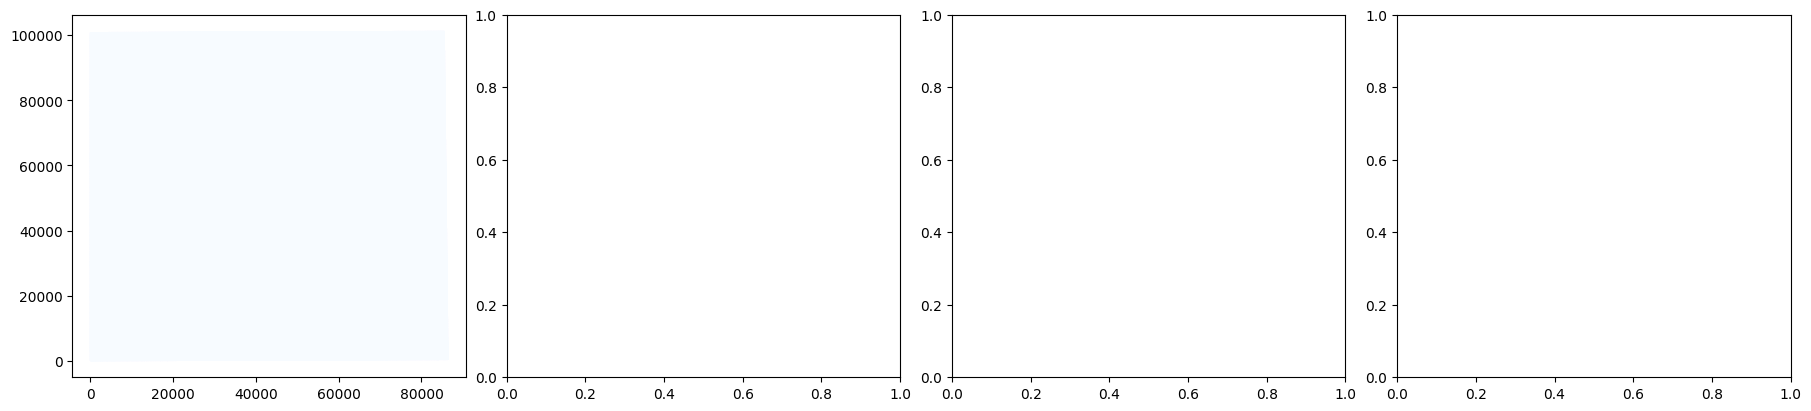

In [2]:
# Create animation from ANUGA output file (like work.ipynb)
# NOTE: Run this cell AFTER running the simulation cell (Cell 4)
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib import animation
from pathlib import Path
from IPython.display import HTML

print("Loading ANUGA simulation output for animation...")

# Load ANUGA simulation output (.sww file)
sww_path = Path('outputs') / 'rainfall_simulation.sww'
if not sww_path.exists():
    print(f"ERROR: Simulation output file not found: {sww_path}")
    print("Please run Cell 4 (simulation cell) first!")
    raise FileNotFoundError(f'Run simulation first to generate {sww_path}')

print(f"Reading {sww_path}...")

with netCDF4.Dataset(sww_path) as ds:
    time = ds.variables['time'][:].copy()
    x = ds.variables['x'][:].copy()
    y = ds.variables['y'][:].copy()
    stage = ds.variables['stage'][:].copy()  # shape (nt, npoints)
    
    # Get bed elevation
    if 'elevation' in ds.variables:
        bed = ds.variables['elevation'][:].copy()
    elif 'bed_elevation' in ds.variables:
        bed = ds.variables['bed_elevation'][:].copy()
    else:
        raise KeyError('Could not find bed elevation in the SWW file.')
    
    volumes = ds.variables['volumes'][:].astype(int)

print(f"Loaded {len(time)} timesteps")

# Create triangulation
tri = Triangulation(x, y, volumes)

# Calculate water depth
depth = np.maximum(stage - bed, 0.0)
max_depth = depth.max()
time_minutes = time / 60.0

print(f"Max depth in simulation: {max_depth:.3f} m")

# ========== SNAPSHOT PLOT ==========
# Show 4 key moments in time
snapshot_indices = np.linspace(0, len(time) - 1, num=4, dtype=int)
fig1, axes = plt.subplots(1, len(snapshot_indices), figsize=(18, 4), constrained_layout=True)
quad = None

for ax, idx in zip(axes, snapshot_indices):
    quad = ax.tripcolor(tri, depth[idx], shading='gouraud', cmap='Blues', vmin=0.0, vmax=max_depth)
    ax.set_title(f't = {time_minutes[idx]:.1f} min', fontsize=13, fontweight='bold')
    ax.set_xlabel('Easting (m)', fontsize=11)
    ax.set_ylabel('Northing (m)', fontsize=11)
    ax.set_aspect('equal')
    
fig1.colorbar(quad, ax=axes.ravel().tolist(), shrink=0.8, label='Water depth (m)')
fig1.suptitle('Surface Water Depth - Key Snapshots', fontsize=15, fontweight='bold')
plt.show()

# ========== ANIMATED PLOT ==========
print("\nCreating animation...")

fig2, ax = plt.subplots(figsize=(10, 8))
plt.rcParams['animation.embed_limit'] = 100.0 
pcm = ax.tripcolor(tri, depth[0], shading='gouraud', cmap='Blues', vmin=0.0, vmax=max_depth)
ax.set_xlabel('Easting (m)', fontsize=12)
ax.set_ylabel('Northing (m)', fontsize=12)
ax.set_aspect('equal')
ax.set_title('Surface Water Routing and Boundary Outflow', fontsize=14, fontweight='bold')

# Time and statistics text
time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                    color='white', fontsize=11, fontweight='bold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

fig2.colorbar(pcm, ax=ax, label='Water depth (m)')

def update_frame(frame_idx):
    """Update animation frame"""
    pcm.set_array(depth[frame_idx])
    
    t = time[frame_idx]
    hours = int(t // 3600)
    mins = int((t % 3600) // 60)
    max_d = depth[frame_idx].max()
    mean_d = depth[frame_idx][depth[frame_idx] > 0.001].mean() if (depth[frame_idx] > 0.001).any() else 0.0
    
    status = "RAINFALL ACTIVE ⬇" if t <= 3600 else "DRAINING ➤"
    time_str = f"Time: {hours:02d}:{mins:02d} | Max: {max_d:.3f}m | Mean: {mean_d:.3f}m\n{status}"
    time_text.set_text(time_str)
    
    return pcm, time_text

# Create animation - sample every few frames for smoother playback
frame_step = max(1, len(time) // 60)  # Show ~60 frames max
frame_indices = range(0, len(time), frame_step)

anim = animation.FuncAnimation(fig2, update_frame, frames=frame_indices, 
                               interval=150, blit=False, repeat=True)

# Display in notebook
print("Displaying animation in notebook...")
display(HTML(anim.to_jshtml()))

# Try to save as GIF
gif_path = Path('outputs') / 'rainfall_animation.gif'
try:
    anim.save(gif_path, writer='pillow', fps=10)
    print(f'\n✓ Animation saved to {gif_path}')
except Exception as exc:
    print(f'\nNote: Could not save GIF ({exc}). Install pillow if needed: pip install pillow')

print("\n" + "="*70)
print("ANIMATION DETAILS")
print("="*70)
print(f"Total timesteps: {len(time)}")
print(f"Simulation duration: {time[-1]/3600:.2f} hours ({time[-1]/60:.1f} minutes)")
print(f"Max depth observed: {max_depth:.4f} m = {max_depth*1000:.2f} mm")
print(f"Frames in animation: {len(frame_indices)}")
print("\nThe animation shows:")
print("  • Water accumulating during rainfall (0-60 min)")
print("  • Water draining through boundaries (60-120 min)")
print("  • Flow routing following terrain elevation")
print("="*70)

In [ ]:
# # Visualize simulation results
# import matplotlib.pyplot as plt
# import matplotlib.tri as tri

# # Convert time to hours
# time_hours = np.array(time_data) / 3600.0

# # Create comprehensive visualization
# fig = plt.figure(figsize=(18, 12))
# gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# # Plot 1: Time series of max depth
# ax1 = fig.add_subplot(gs[0, 0])
# ax1.plot(time_hours, max_depth_data, 'b-', linewidth=2)
# ax1.axvline(x=1.0, color='r', linestyle='--', linewidth=1.5, label='Rain stops', alpha=0.7)
# ax1.set_xlabel('Time (hours)', fontsize=12)
# ax1.set_ylabel('Maximum Depth (m)', fontsize=12)
# ax1.set_title('Maximum Water Depth Over Time', fontsize=13, fontweight='bold')
# ax1.grid(True, alpha=0.3)
# ax1.legend(fontsize=10)
# ax1.set_xlim(0, 2)

# # Plot 2: Time series of total volume
# ax2 = fig.add_subplot(gs[0, 1])
# ax2.plot(time_hours, np.array(total_volume_data)/1e6, 'g-', linewidth=2)
# ax2.axvline(x=1.0, color='r', linestyle='--', linewidth=1.5, label='Rain stops', alpha=0.7)
# ax2.set_xlabel('Time (hours)', fontsize=12)
# ax2.set_ylabel('Total Water Volume (million m³)', fontsize=12)
# ax2.set_title('Total Water Volume Over Time', fontsize=13, fontweight='bold')
# ax2.grid(True, alpha=0.3)
# ax2.legend(fontsize=10)
# ax2.set_xlim(0, 2)

# # Get mesh for spatial plots
# points = domain.get_vertex_coordinates()
# triangles = domain.get_triangles()
# x = points[:, 0]
# y = points[:, 1]
# triang = tri.Triangulation(x, y, triangles)

# # Get final state
# stage_final = domain.get_quantity('stage').get_values(location='centroids')
# elev_final = domain.get_quantity('elevation').get_values(location='centroids')
# depth_final = np.maximum(stage_final - elev_final, 0.0)

# # Plot 3: Final water depth distribution
# ax3 = fig.add_subplot(gs[1, :])
# tcf = ax3.tripcolor(triang, depth_final, cmap='Blues', shading='flat', vmin=0)
# ax3.set_xlabel('Easting (m)', fontsize=12)
# ax3.set_ylabel('Northing (m)', fontsize=12)
# ax3.set_title('Water Depth at End of Simulation (t = 2 hours)', fontsize=13, fontweight='bold')
# ax3.set_aspect('equal')
# cbar = plt.colorbar(tcf, ax=ax3, orientation='horizontal', pad=0.05)
# cbar.set_label('Water Depth (m)', fontsize=11)

# # Plot 4: Elevation (for reference)
# ax4 = fig.add_subplot(gs[2, 0])
# tcf2 = ax4.tripcolor(triang, elev_final, cmap='terrain', shading='flat')
# ax4.set_xlabel('Easting (m)', fontsize=11)
# ax4.set_ylabel('Northing (m)', fontsize=11)
# ax4.set_title('Terrain Elevation (Reference)', fontsize=12, fontweight='bold')
# ax4.set_aspect('equal')
# cbar2 = plt.colorbar(tcf2, ax=ax4)
# cbar2.set_label('Elevation (m)', fontsize=10)

# # Plot 5: Final stage (water surface elevation)
# ax5 = fig.add_subplot(gs[2, 1])
# tcf3 = ax5.tripcolor(triang, stage_final, cmap='viridis', shading='flat')
# ax5.set_xlabel('Easting (m)', fontsize=11)
# ax5.set_ylabel('Northing (m)', fontsize=11)
# ax5.set_title('Water Surface Elevation at t = 2 hours', fontsize=12, fontweight='bold')
# ax5.set_aspect('equal')
# cbar3 = plt.colorbar(tcf3, ax=ax5)
# cbar3.set_label('Stage (m)', fontsize=10)

# plt.suptitle('Rainfall-Runoff Simulation: 10 mm/hr for 1 hour', 
#              fontsize=16, fontweight='bold', y=0.995)
# # 
# plt.show()

# # Print summary statistics
# print("\n" + "="*70)
# print("SIMULATION SUMMARY")
# print("="*70)
# print(f"Initial condition: Dry bed")
# print(f"Rainfall: 10 mm/hr for 1 hour")
# print(f"Total rainfall input: {10 * domain.get_area()/1e6:.2f} million m³")
# print(f"\nFinal results (t = 2 hours):")
# print(f"  Maximum water depth: {depth_final.max():.4f} m = {depth_final.max()*1000:.2f} mm")
# print(f"  Mean water depth: {depth_final.mean():.4f} m = {depth_final.mean()*1000:.2f} mm")
# print(f"  Total water volume: {total_volume_data[-1]/1e6:.2f} million m³")
# print(f"  Percentage retained: {100*total_volume_data[-1]/(10*domain.get_area()/1e6):.1f}%")
# print(f"  (Rest drained through boundaries)")
# print("="*70)

In [ ]:
# Visualize the triangulated mesh
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# Get mesh coordinates and triangles
points = domain.get_vertex_coordinates()
triangles = domain.get_triangles()

# Reshape points to x, y coordinates
x = points[:, 0]
y = points[:, 1]

# Create triangulation for plotting
triang = tri.Triangulation(x, y, triangles)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Mesh triangulation
ax1.triplot(triang, 'b-', linewidth=0.3, alpha=0.5)
ax1.set_xlabel('Easting (m)', fontsize=12)
ax1.set_ylabel('Northing (m)', fontsize=12)
ax1.set_title(f'Triangulated Mesh\n({domain.get_number_of_triangles():,} triangles)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: Elevation on mesh
elevation_values = domain.get_quantity('elevation').get_values(location='centroids')
tcf = ax2.tripcolor(triang, elevation_values, cmap='terrain', shading='flat')
ax2.set_xlabel('Easting (m)', fontsize=12)
ax2.set_ylabel('Northing (m)', fontsize=12)
ax2.set_title('Elevation on Mesh', fontsize=14, fontweight='bold')
ax2.set_aspect('equal')
cbar = plt.colorbar(tcf, ax=ax2)
cbar.set_label('Elevation (m)', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nMesh Statistics:")
print(f"  Total triangles: {domain.get_number_of_triangles():,}")
print(f"  Total vertices: {len(x):,}")
print(f"  Domain area: {domain.get_area():,.2f} m²")
print(f"  Domain area: {domain.get_area()/1e6:.2f} km²")

In [ ]:
# # Compare: Irregular (Delaunay) vs Regular Grid
# import matplotlib.pyplot as plt
# import matplotlib.tri as tri
# import matplotlib.patches as patches

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Get actual mesh data
# points = domain.get_vertex_coordinates()
# triangles = domain.get_triangles()
# x = points[:, 0]
# y = points[:, 1]
# triang = tri.Triangulation(x, y, triangles)

# # Plot 1: Zoomed view of actual irregular mesh
# ax1 = axes[0]
# # Zoom into a small region to see triangle detail
# x_min, x_max = 520000, 540000
# y_min, y_max = 3340000, 3360000
# ax1.triplot(triang, 'b-', linewidth=0.5)
# ax1.set_xlim(x_min, x_max)
# ax1.set_ylim(y_min, y_max)
# ax1.set_xlabel('Easting (m)', fontsize=11)
# ax1.set_ylabel('Northing (m)', fontsize=11)
# ax1.set_title('ANUGA Irregular Triangulation\n(Delaunay - Adaptive)', fontsize=13, fontweight='bold', color='blue')
# ax1.grid(True, alpha=0.3)
# ax1.set_aspect('equal')
# ax1.text(0.5, 0.95, 'High quality triangles\nAdapts to boundaries', 
#          transform=ax1.transAxes, ha='center', va='top', 
#          bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), fontsize=9)

# # Plot 2: Simulated regular grid (for comparison)
# ax2 = axes[1]
# # Create a simple regular grid
# grid_spacing = 2000  # meters
# x_grid = np.arange(x_min, x_max, grid_spacing)
# y_grid = np.arange(y_min, y_max, grid_spacing)
# for xi in x_grid:
#     ax2.plot([xi, xi], [y_min, y_max], 'r-', linewidth=0.5, alpha=0.6)
# for yi in y_grid:
#     ax2.plot([x_min, x_max], [yi, yi], 'r-', linewidth=0.5, alpha=0.6)
# ax2.set_xlim(x_min, x_max)
# ax2.set_ylim(y_min, y_max)
# ax2.set_xlabel('Easting (m)', fontsize=11)
# ax2.set_ylabel('Northing (m)', fontsize=11)
# ax2.set_title('Regular Grid (Hypothetical)\n(Uniform - Not Adaptive)', fontsize=13, fontweight='bold', color='red')
# ax2.grid(True, alpha=0.3)
# ax2.set_aspect('equal')
# ax2.text(0.5, 0.95, 'Wastes computation\nPoor boundary fit', 
#          transform=ax2.transAxes, ha='center', va='top',
#          bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7), fontsize=9)

# # Plot 3: Full domain showing boundary conformance
# ax3 = axes[2]
# ax3.triplot(triang, 'b-', linewidth=0.2, alpha=0.3)
# # Highlight the boundary
# boundary_points = domain.get_boundary_polygon()
# if len(boundary_points) > 0:
#     bx = [p[0] for p in boundary_points] + [boundary_points[0][0]]
#     by = [p[1] for p in boundary_points] + [boundary_points[0][1]]
#     ax3.plot(bx, by, 'r-', linewidth=3, label='Domain Boundary')
# ax3.set_xlabel('Easting (m)', fontsize=11)
# ax3.set_ylabel('Northing (m)', fontsize=11)
# ax3.set_title('Full Domain with Boundary\n(Perfect Fit to Irregular Shape)', fontsize=13, fontweight='bold')
# ax3.legend(fontsize=10)
# ax3.set_aspect('equal')
# ax3.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# print("\n" + "="*70)
# print("WHY IRREGULAR (DELAUNAY) TRIANGULATION?")
# print("="*70)
# print("\n✓ ADVANTAGES OF ANUGA'S APPROACH:")
# print("  1. Exact boundary conformance - fits your QGIS polygon perfectly")
# print("  2. High-quality triangles - avoids thin/distorted elements")
# print("  3. Flexible resolution - can refine specific areas if needed")
# print("  4. Better terrain representation - adapts to topographic features")
# print("  5. Computationally stable - good triangle angles prevent errors")
# print("\n✗ PROBLEMS WITH REGULAR GRIDS:")
# print("  1. Cannot fit irregular boundaries exactly")
# print("  2. Wastes computation on uniform resolution everywhere")
# print("  3. Poor representation of curved features")
# print("  4. Either leaves gaps or forces domain to be rectangular")
# print("\n" + "="*70)
# print(f"Your mesh: {domain.get_number_of_triangles():,} adaptive triangles")
# print(f"Equivalent regular grid: Would need ~2-3x more cells for same accuracy")
# print("="*70)

In [ ]:
# VERIFY GPU SETUP, FORCE GPU INTERFACE, AND PREWARM KERNELS
# This cell ensures the GPU interface is created even if set_multiprocessor_mode
# fell back to CPU previously. It also prewarms GPU kernels so they are compiled
# and resident prior to the long simulation.

# Quick config knobs (adjust if you want heavier prewarm/load)
config.prewarm_iterations = getattr(config, 'prewarm_iterations', 8)   # number of small kernel calls to prewarm
config.prewarm_edge_calls = getattr(config, 'prewarm_edge_calls', 2)   # call extrapolation kernels this many times
config.force_gpu_init = getattr(config, 'force_gpu_init', True)       # force manual GPU init if set_multiprocessor_mode didn't

# Check GPU availability regardless of config.use_gpu (which might have been disabled by fallback)
if GPU_AVAILABLE:
    print('='*70)
    print('GPU VERIFICATION & FORCED INIT')
    print('='*70)
    import cupy as cp
    
    if not config.use_gpu:
        print("⚠ Note: config.use_gpu was False (likely due to fallback). Attempting to FORCE GPU...")
        config.use_gpu = True

    # Try to set multiprocessor mode first (preferred path)
    try:
        domain.set_multiprocessor_mode(2)
    except Exception as e:
        print(f'Warning: domain.set_multiprocessor_mode(2) raised: {e}')

    # If domain did not end up in GPU mode or no gpu_interface exists, try manual creation
    if getattr(domain, 'get_multiprocessor_mode', lambda: None)() != 2 or getattr(domain, 'gpu_interface', None) is None:
        if not config.force_gpu_init:
            print('Multiprocessor mode not GPU and force init disabled - skipping manual GPU init')
        else:
            print('Multiprocessor mode is not 2 or gpu_interface missing — attempting manual GPU interface creation...')
            try:
                from anuga.shallow_water.sw_domain_cuda import GPU_interface
                domain.gpu_interface = GPU_interface(domain)
                # allocate arrays and compile kernels
                print('Allocating GPU arrays (this may take a moment)...')
                domain.gpu_interface.allocate_gpu_arrays()
                print('Compiling GPU kernels (this may take a moment)...')
                try:
                    domain.gpu_interface.compile_gpu_kernels()
                except Exception as ce:
                    # Compilation may expect different path to cuda_anuga.cu on your system
                    print(f'Warning: kernel compilation failed: {ce}')
                    print('Kernels may still be available if precompiled cubin is found elsewhere.')
                # force set the mode marker
                domain.multiprocessor_mode = 2
                print('✓ Manual GPU interface created and arrays allocated (if no exceptions)')
            except Exception as e:
                import traceback
                print(f'✗ Manual GPU init failed: {e}')
                traceback.print_exc()
                print('Falling back to CPU mode')
                try:
                    import multiprocessing
                    num_threads = multiprocessing.cpu_count()
                    domain.set_omp_num_threads(num_threads)
                    print(f"✓ CPU mode: Using {num_threads} OpenMP threads")
                except:
                    pass
                config.use_gpu = False

    # If we have a gpu_interface, do a prewarm sequence to compile/load kernels and allocate memory
    if getattr(domain, 'gpu_interface', None) is not None and getattr(domain, 'get_multiprocessor_mode', lambda: 1)() == 2:
        gi = domain.gpu_interface

        # Quick memory snapshot before prewarm
        try:
            mempool = cp.get_default_memory_pool()
            print('\nGPU memory before prewarm:')
            print(f"  Used: {mempool.used_bytes()/1e6:.1f} MB | Total tracked: {mempool.total_bytes()/1e6:.1f} MB")
        except Exception:
            pass

        # Ensure GPU arrays reflect current CPU values
        try:
            gi.cpu_to_gpu_centroid_values()
            gi.cpu_to_gpu_edge_values()
            gi.cpu_to_gpu_boundary_values()
        except Exception as e:
            print(f'Warning: failed to copy CPU->GPU initial arrays: {e}')

        # Prewarm compute_fluxes kernel a number of times
        print('\nPrewarming flux kernel...')
        prewarm_iters = max(1, int(config.prewarm_iterations))
        for i in range(prewarm_iters):
            try:
                # Use transfer_gpu_results=False for prewarm to avoid expensive host transfers
                _ = gi.compute_fluxes_ext_central_kernel(domain.timestep, transfer_from_cpu=False, transfer_gpu_results=False)
            except Exception as e:
                # If transfer_from_cpu=False fails (some arrays not set), try with transfer_from_cpu=True
                try:
                    _ = gi.compute_fluxes_ext_central_kernel(domain.timestep, transfer_from_cpu=True, transfer_gpu_results=False)
                except Exception as e2:
                    print(f'Prewarm iteration {i} failed: {e2}')
                    break
        print('Done prewarming flux kernel')

        # Prewarm extrapolation kernels (these are used frequently)
        print('\nPrewarming extrapolation kernels...')
        for j in range(max(1, int(config.prewarm_edge_calls))):
            try:
                gi.extrapolate_second_order_edge_sw_kernel(transfer_from_cpu=False, transfer_gpu_results=False)
            except Exception:
                try:
                    gi.extrapolate_second_order_edge_sw_kernel(transfer_from_cpu=True, transfer_gpu_results=False)
                except Exception as e:
                    print(f'Extrapolation prewarm failed: {e}')
                    break
        print('Done prewarming extrapolation kernels')

        # Show memory after prewarm
        try:
            mempool_after = cp.get_default_memory_pool()
            print('\nGPU memory after prewarm:')
            print(f"  Used: {mempool_after.used_bytes()/1e6:.1f} MB | Total tracked: {mempool_after.total_bytes()/1e6:.1f} MB")
        except Exception:
            pass

        print('\nPrewarm complete — now proceed to full simulation.\n')
        print('💡 TIP: While running the full simulation, open a terminal and run `nvidia-smi -l 1` to watch GPU usage live.')

    else:
        print('\nGPU interface not present or not in GPU mode; cannot prewarm kernels')
        print(f'  Multiprocessor mode: {getattr(domain, "get_multiprocessor_mode", lambda: 1)()}')
        print(f'  gpu_interface: {getattr(domain, "gpu_interface", None)}')

else:
    print('GPU not enabled or not available - skipping verification/prewarm')
    print(f'Config use_gpu: {config.use_gpu}')
    print(f'GPU available: {GPU_AVAILABLE}')
    if hasattr(domain, 'get_multiprocessor_mode'):
        print(f'Multiprocessor mode: {domain.get_multiprocessor_mode()}')

In [ ]:
# import os
# from osgeo import gdal
# import pandas as pd
# from shapely import wkt

# # 1. CHECK TIF EXTENT
# tif_path = "DEM_UTM.tif"
# if os.path.exists(tif_path):
#     ds = gdal.Open(tif_path)
#     gt = ds.GetGeoTransform()
#     # gt[0] = min_x, gt[3] = max_y
#     min_x = gt[0]
#     max_y = gt[3]
#     max_x = min_x + (gt[1] * ds.RasterXSize)
#     min_y = max_y + (gt[5] * ds.RasterYSize)
    
#     print(f"--- DIAGNOSTIC REPORT ---")
#     print(f"TIF Bounds (X): {min_x:.2f} to {max_x:.2f}")
#     print(f"TIF Bounds (Y): {min_y:.2f} to {max_y:.2f}")
# else:
#     print("TIF file not found.")

# # 2. CHECK POLYGON EXTENT
# df = pd.read_csv("bounder.csv")
# poly = wkt.loads(df['WKT'].iloc[0])
# bounds = poly.bounds # (minx, miny, maxx, maxy)
# print(f"Poly Bounds (X): {bounds[0]:.2f} to {bounds[2]:.2f}")
# print(f"Poly Bounds (Y): {bounds[1]:.2f} to {bounds[3]:.2f}")

# # VERDICT
# if bounds[0] > max_x or bounds[2] < min_x:
#     print("\n!!! CRITICAL ERROR DETECTED !!!")
#     print("Your Polygon and TIF do not overlap.")
#     print("Likely cause: One is in Meters (UTM), the other is in Degrees (Lat/Lon).")

In [ ]:
# import anuga, os
# print("anuga module file:", getattr(anuga, "__file__", "no __file__"))
# try:
#     print("anuga version:", getattr(anuga, "__version__", "no __version__"))
# except Exception:
#     pass
# print("top-level names containing 'Domain' or 'Geo':",
#       [n for n in dir(anuga) if 'Domain' in n or 'Geo' in n or 'geo' in n.lower()][:40])

# print("cwd files:", os.listdir('.'))



# # import os

# # def fix_asc_header(file_path, nodata_val=-9999):
# #     """
# #     Inserts a NODATA_value header into an ASC file if it's missing.
# #     """
# #     # Read the file into memory
# #     with open(file_path, 'r') as f:
# #         lines = f.readlines()

# #     # Check the 6th line (index 5)
# #     # Standard ASC files usually have 'NODATA_value' here.
# #     # If yours has a number (data), it's missing the header.
# #     header_candidate = lines[5].strip().split()
    
# #     # Simple heuristic: if the first part of the 6th line is a number, 
# #     # we assume it's data and the header is missing.
# #     try:
# #         float(header_candidate[0])
# #         is_data = True
# #     except ValueError:
# #         is_data = False

# #     if is_data:
# #         print(f"Diagnosis: 'NODATA_value' header missing in {file_path}.")
# #         print("Patching file...")
        
# #         # Insert the NODATA line at index 5 (6th line)
# #         lines.insert(5, f"NODATA_value {nodata_val}\n")
        
# #         # Write the corrected lines back to the file
# #         # We write to a new file first to be safe
# #         new_filename = file_path.replace(".asc", "_fixed.asc")
# #         with open(new_filename, 'w') as f:
# #             f.writelines(lines)
            
# #         print(f"Success! Fixed file saved as: {new_filename}")
# #         print(f"Please update your code to use: {new_filename}")
        
# #     else:
# #         print("File seems to have a non-numeric 6th line. It might already be correct or have a different issue.")
# #         print(f"Line 6 content: {lines[5]}")

# # # --- Run the Fix ---
# # file_to_fix = "DEM_ROI.asc"
# # fix_asc_header(file_to_fix)